In [35]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sumanthvrao/daily-climate-time-series-data/DailyDelhiClimateTrain.csv
/kaggle/input/datasets/sumanthvrao/daily-climate-time-series-data/DailyDelhiClimateTest.csv


In [36]:
df =pd.read_csv("/kaggle/input/datasets/sumanthvrao/daily-climate-time-series-data/DailyDelhiClimateTrain.csv")

In [37]:
df.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          1462 non-null   object 
 1   meantemp      1462 non-null   float64
 2   humidity      1462 non-null   float64
 3   wind_speed    1462 non-null   float64
 4   meanpressure  1462 non-null   float64
dtypes: float64(4), object(1)
memory usage: 57.2+ KB


In [39]:
df2=df.set_index("date")

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          1462 non-null   object 
 1   meantemp      1462 non-null   float64
 2   humidity      1462 non-null   float64
 3   wind_speed    1462 non-null   float64
 4   meanpressure  1462 non-null   float64
dtypes: float64(4), object(1)
memory usage: 57.2+ KB


In [41]:
df['date']=pd.to_datetime(df['date'])

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          1462 non-null   datetime64[ns]
 1   meantemp      1462 non-null   float64       
 2   humidity      1462 non-null   float64       
 3   wind_speed    1462 non-null   float64       
 4   meanpressure  1462 non-null   float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 57.2 KB


In [45]:
df.set_index('date',inplace=True)

KeyError: "None of ['date'] are in the columns"

In [46]:
df

,meantemp,humidity,wind_speed,meanpressure
date,,,,
2013-01-01,10.000000,84.500000,0.000000,1015.666667
2013-01-02,7.400000,92.000000,2.980000,1017.800000
2013-01-03,7.166667,87.000000,4.633333,1018.666667
2013-01-04,8.666667,71.333333,1.233333,1017.166667
2013-01-05,6.000000,86.833333,3.700000,1016.500000
...,...,...,...,...
2016-12-28,17.217391,68.043478,3.547826,1015.565217
2016-12-29,15.238095,87.857143,6.000000,1016.904762
2016-12-30,14.095238,89.666667,6.266667,1017.904762


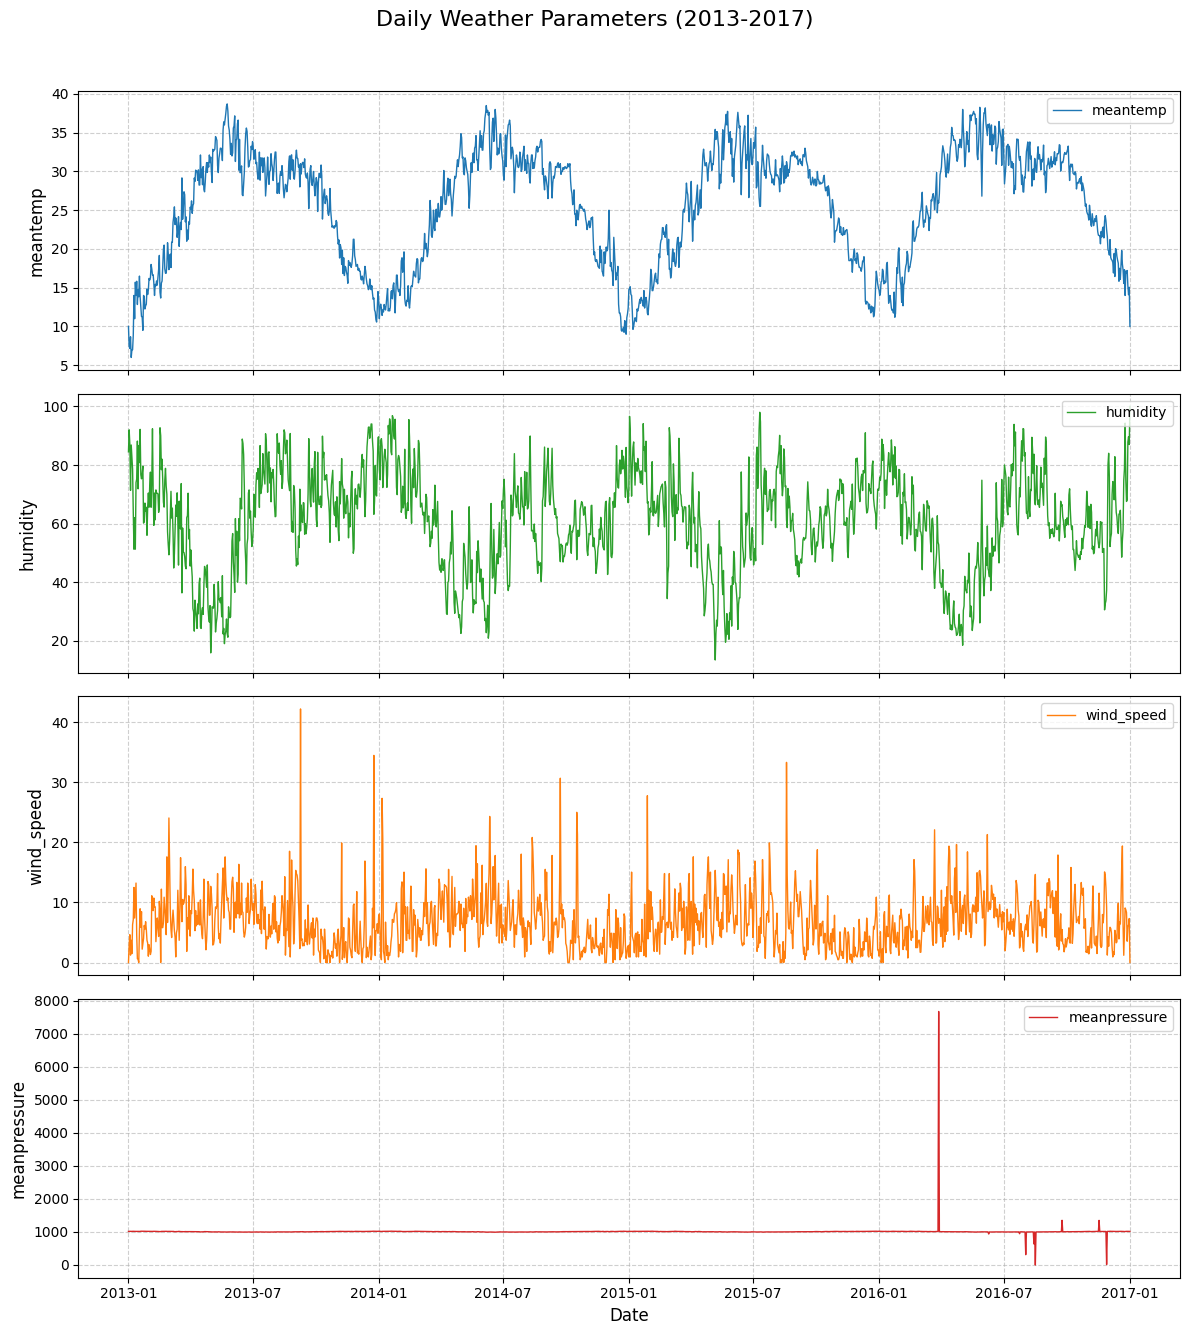

In [47]:

fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(12, 14), sharex=True)

cols = ['meantemp', 'humidity', 'wind_speed', 'meanpressure']
colors = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728']

for ax, col, color in zip(axes, cols, colors):
    ax.plot(df.index, df[col], label=col, color=color, linewidth=1)
    ax.set_ylabel(col, fontsize=12)
    ax.legend(loc='upper right')
    ax.grid(True, linestyle='--', alpha=0.6)

plt.xlabel('Date', fontsize=12)
plt.suptitle('Daily Weather Parameters (2013-2017)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

In [70]:
df['min_temp_15day_ma']=df['meantemp'].rolling(window=15).mean()

In [62]:
df

,meantemp,humidity,wind_speed,meanpressure,min_temp__5day_ma
date,,,,,
2013-01-01,10.000000,84.500000,0.000000,1015.666667,NaN
2013-01-02,7.400000,92.000000,2.980000,1017.800000,NaN
2013-01-03,7.166667,87.000000,4.633333,1018.666667,NaN
2013-01-04,8.666667,71.333333,1.233333,1017.166667,NaN
2013-01-05,6.000000,86.833333,3.700000,1016.500000,7.846667
...,...,...,...,...,...
2016-12-28,17.217391,68.043478,3.547826,1015.565217,16.505686
2016-12-29,15.238095,87.857143,6.000000,1016.904762,16.089669
2016-12-30,14.095238,89.666667,6.266667,1017.904762,16.108716


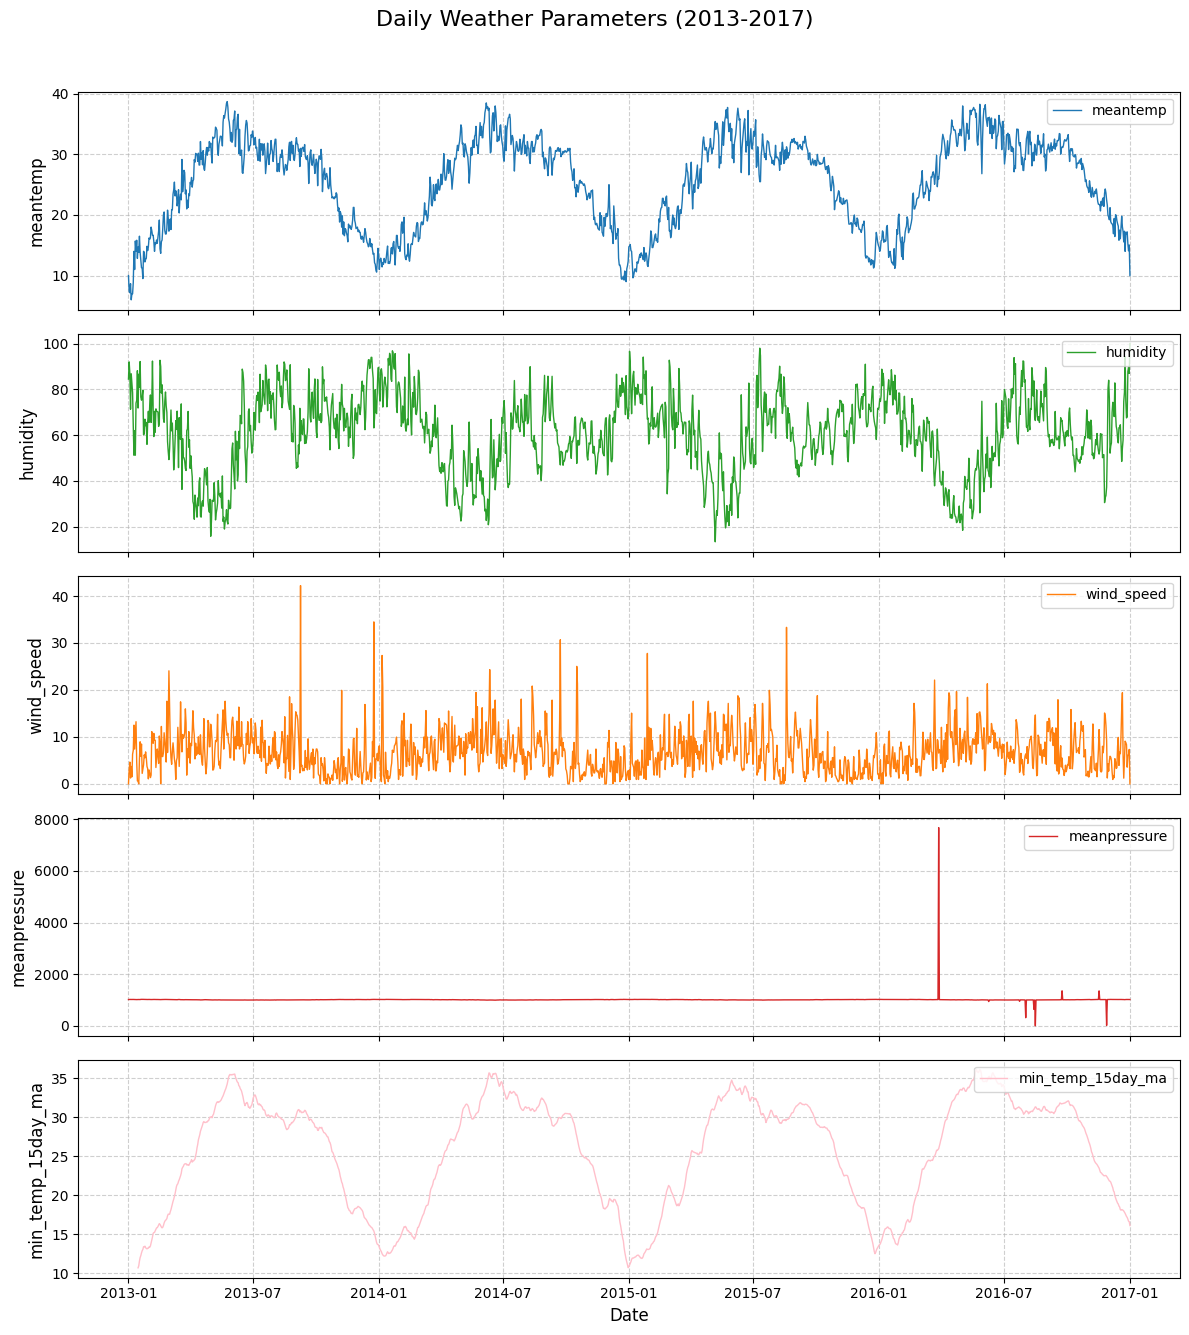

In [71]:

fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(12, 14), sharex=True)

cols = ['meantemp', 'humidity', 'wind_speed', 'meanpressure','min_temp_15day_ma']
colors = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728','pink']

for ax, col, color in zip(axes, cols, colors):
    ax.plot(df.index, df[col], label=col, color=color, linewidth=1)
    ax.set_ylabel(col, fontsize=12)
    ax.legend(loc='upper right')
    ax.grid(True, linestyle='--', alpha=0.6)

plt.xlabel('Date', fontsize=12)
plt.suptitle('Daily Weather Parameters (2013-2017)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

In [74]:
df['temp_diff']=df['meantemp'].diff()

In [87]:
df['temp_1day_bef']=df['meantemp'].shift()

In [89]:
df[['temp_1day_bef','meantemp']]

,temp_1day_bef,meantemp
date,,
2013-01-01,NaN,10.000000
2013-01-02,10.000000,7.400000
2013-01-03,7.400000,7.166667
2013-01-04,7.166667,8.666667
2013-01-05,8.666667,6.000000
...,...,...
2016-12-28,16.850000,17.217391
2016-12-29,17.217391,15.238095
2016-12-30,15.238095,14.095238


In [76]:
df[['meantemp','temp_diff']]

,meantemp,temp_diff
date,,
2013-01-01,10.000000,NaN
2013-01-02,7.400000,-2.600000
2013-01-03,7.166667,-0.233333
2013-01-04,8.666667,1.500000
2013-01-05,6.000000,-2.666667
...,...,...
2016-12-28,17.217391,0.367391
2016-12-29,15.238095,-1.979296
2016-12-30,14.095238,-1.142857


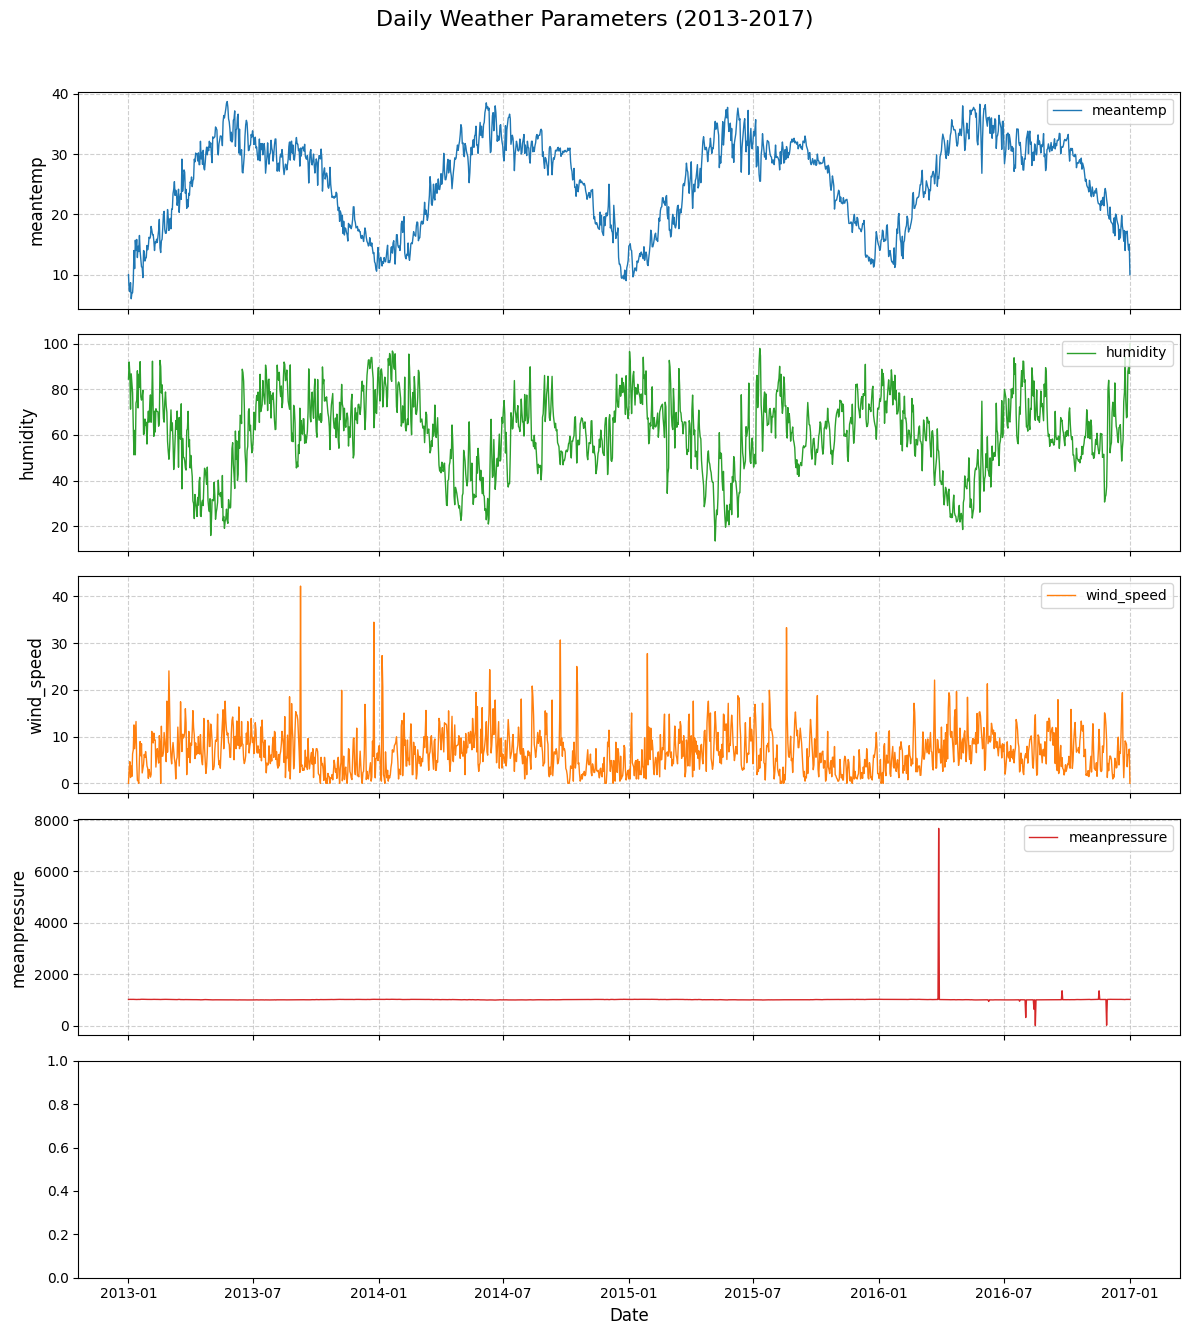

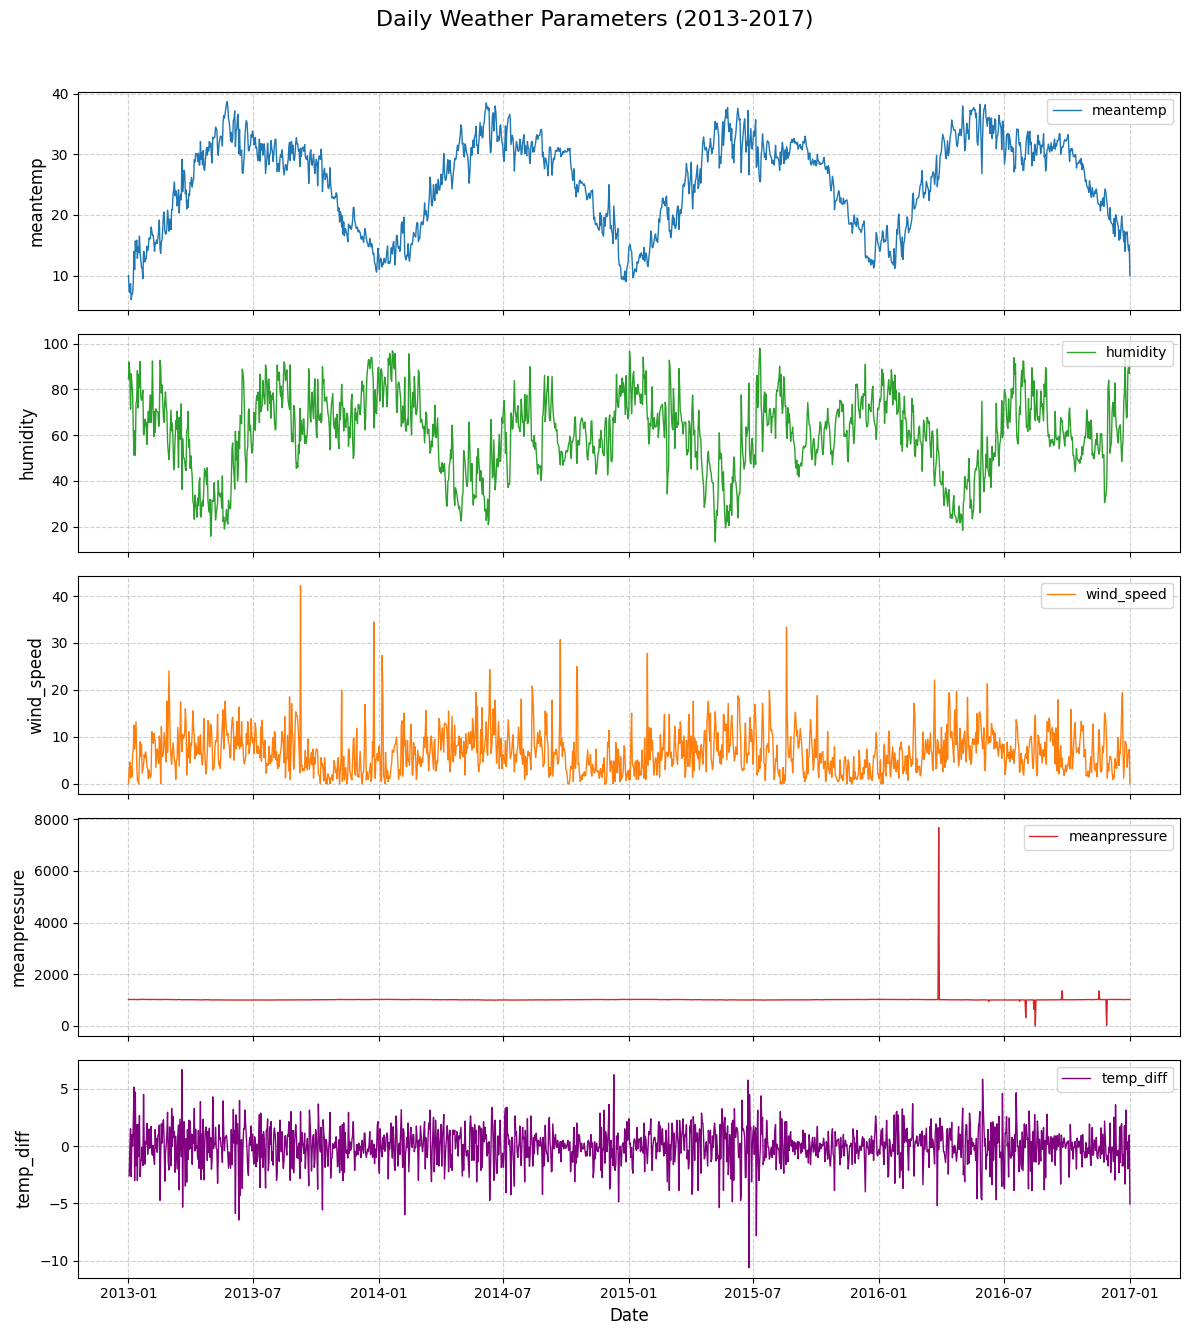

In [77]:

fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(12, 14), sharex=True)

cols = ['meantemp', 'humidity', 'wind_speed', 'meanpressure']
colors = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728']

for ax, col, color in zip(axes, cols, colors):
    ax.plot(df.index, df[col], label=col, color=color, linewidth=1)
    ax.set_ylabel(col, fontsize=12)
    ax.legend(loc='upper right')
    ax.grid(True, linestyle='--', alpha=0.6)

plt.xlabel('Date', fontsize=12)
plt.suptitle('Daily Weather Parameters (2013-2017)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(12, 14), sharex=True)

cols = ['meantemp', 'humidity', 'wind_speed', 'meanpressure','temp_diff']
colors = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728','purple']

for ax, col, color in zip(axes, cols, colors):
    ax.plot(df.index, df[col], label=col, color=color, linewidth=1)
    ax.set_ylabel(col, fontsize=12)
    ax.legend(loc='upper right')
    ax.grid(True, linestyle='--', alpha=0.6)

plt.xlabel('Date', fontsize=12)
plt.suptitle('Daily Weather Parameters (2013-2017)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

In [83]:
df['meantemp'].autocorr(10)

np.float64(0.9012661699407912)

In [84]:
df['min_temp__5day_ma'].bfill()

date
2013-01-01     7.846667
2013-01-02     7.846667
2013-01-03     7.846667
2013-01-04     7.846667
2013-01-05     7.846667
                ...    
2016-12-28    16.505686
2016-12-29    16.089669
2016-12-30    16.108716
2016-12-31    15.690671
2017-01-01    14.320671
Name: min_temp__5day_ma, Length: 1462, dtype: float64

In [91]:
df.bfill(inplace=True)

In [92]:
df

,meantemp,humidity,wind_speed,meanpressure,min_temp__5day_ma,min_temp_15day_ma,temp_diff,temp_1day_bef
date,,,,,,,,
2013-01-01,10.000000,84.500000,0.000000,1015.666667,7.846667,10.679048,-2.600000,10.000000
2013-01-02,7.400000,92.000000,2.980000,1017.800000,7.846667,10.679048,-2.600000,10.000000
2013-01-03,7.166667,87.000000,4.633333,1018.666667,7.846667,10.679048,-0.233333,7.400000
2013-01-04,8.666667,71.333333,1.233333,1017.166667,7.846667,10.679048,1.500000,7.166667
2013-01-05,6.000000,86.833333,3.700000,1016.500000,7.846667,10.679048,-2.666667,8.666667
...,...,...,...,...,...,...,...,...
2016-12-28,17.217391,68.043478,3.547826,1015.565217,16.505686,17.147345,0.367391,16.850000
2016-12-29,15.238095,87.857143,6.000000,1016.904762,16.089669,16.926181,-1.979296,17.217391
2016-12-30,14.095238,89.666667,6.266667,1017.904762,16.108716,16.654752,-1.142857,15.238095


In [94]:
from xgboost import XGBRegressor

In [96]:
model= XGBRegressor()

In [104]:
df

,meantemp,humidity,wind_speed,meanpressure,min_temp__5day_ma,min_temp_15day_ma,temp_diff,temp_1day_bef,target_col_temp
date,,,,,,,,,
2013-01-01,10.000000,84.500000,0.000000,1015.666667,7.846667,10.679048,-2.600000,10.000000,7.400000
2013-01-02,7.400000,92.000000,2.980000,1017.800000,7.846667,10.679048,-2.600000,10.000000,7.166667
2013-01-03,7.166667,87.000000,4.633333,1018.666667,7.846667,10.679048,-0.233333,7.400000,8.666667
2013-01-04,8.666667,71.333333,1.233333,1017.166667,7.846667,10.679048,1.500000,7.166667,6.000000
2013-01-05,6.000000,86.833333,3.700000,1016.500000,7.846667,10.679048,-2.666667,8.666667,7.000000
...,...,...,...,...,...,...,...,...,...
2016-12-27,16.850000,67.550000,8.335000,1017.200000,16.172208,17.269519,-0.292857,17.142857,17.217391
2016-12-28,17.217391,68.043478,3.547826,1015.565217,16.505686,17.147345,0.367391,16.850000,15.238095
2016-12-29,15.238095,87.857143,6.000000,1016.904762,16.089669,16.926181,-1.979296,17.217391,14.095238


In [105]:
df['templag1']=df['meantemp'].shift(1)
df['humiditylag1']=df['humidity'].shift(1)
df['meanpressurelag1']=df['meanpressure'].shift(1)

In [106]:
df

,meantemp,humidity,wind_speed,meanpressure,min_temp__5day_ma,min_temp_15day_ma,temp_diff,temp_1day_bef,target_col_temp,templag1,humiditylag1,meanpressurelag1
date,,,,,,,,,,,,
2013-01-01,10.000000,84.500000,0.000000,1015.666667,7.846667,10.679048,-2.600000,10.000000,7.400000,NaN,NaN,NaN
2013-01-02,7.400000,92.000000,2.980000,1017.800000,7.846667,10.679048,-2.600000,10.000000,7.166667,10.000000,84.500000,1015.666667
2013-01-03,7.166667,87.000000,4.633333,1018.666667,7.846667,10.679048,-0.233333,7.400000,8.666667,7.400000,92.000000,1017.800000
2013-01-04,8.666667,71.333333,1.233333,1017.166667,7.846667,10.679048,1.500000,7.166667,6.000000,7.166667,87.000000,1018.666667
2013-01-05,6.000000,86.833333,3.700000,1016.500000,7.846667,10.679048,-2.666667,8.666667,7.000000,8.666667,71.333333,1017.166667
...,...,...,...,...,...,...,...,...,...,...,...,...
2016-12-27,16.850000,67.550000,8.335000,1017.200000,16.172208,17.269519,-0.292857,17.142857,17.217391,17.142857,74.857143,1016.952381
2016-12-28,17.217391,68.043478,3.547826,1015.565217,16.505686,17.147345,0.367391,16.850000,15.238095,16.850000,67.550000,1017.200000
2016-12-29,15.238095,87.857143,6.000000,1016.904762,16.089669,16.926181,-1.979296,17.217391,14.095238,17.217391,68.043478,1015.565217


In [100]:
df['target_col_temp']=df['meantemp'].shift(-1)

In [107]:
df

,meantemp,humidity,wind_speed,meanpressure,min_temp__5day_ma,min_temp_15day_ma,temp_diff,temp_1day_bef,target_col_temp,templag1,humiditylag1,meanpressurelag1
date,,,,,,,,,,,,
2013-01-01,10.000000,84.500000,0.000000,1015.666667,7.846667,10.679048,-2.600000,10.000000,7.400000,NaN,NaN,NaN
2013-01-02,7.400000,92.000000,2.980000,1017.800000,7.846667,10.679048,-2.600000,10.000000,7.166667,10.000000,84.500000,1015.666667
2013-01-03,7.166667,87.000000,4.633333,1018.666667,7.846667,10.679048,-0.233333,7.400000,8.666667,7.400000,92.000000,1017.800000
2013-01-04,8.666667,71.333333,1.233333,1017.166667,7.846667,10.679048,1.500000,7.166667,6.000000,7.166667,87.000000,1018.666667
2013-01-05,6.000000,86.833333,3.700000,1016.500000,7.846667,10.679048,-2.666667,8.666667,7.000000,8.666667,71.333333,1017.166667
...,...,...,...,...,...,...,...,...,...,...,...,...
2016-12-27,16.850000,67.550000,8.335000,1017.200000,16.172208,17.269519,-0.292857,17.142857,17.217391,17.142857,74.857143,1016.952381
2016-12-28,17.217391,68.043478,3.547826,1015.565217,16.505686,17.147345,0.367391,16.850000,15.238095,16.850000,67.550000,1017.200000
2016-12-29,15.238095,87.857143,6.000000,1016.904762,16.089669,16.926181,-1.979296,17.217391,14.095238,17.217391,68.043478,1015.565217


In [101]:
df['target_col_temp']

date
2013-01-01     7.400000
2013-01-02     7.166667
2013-01-03     8.666667
2013-01-04     6.000000
2013-01-05     7.000000
                ...    
2016-12-28    15.238095
2016-12-29    14.095238
2016-12-30    15.052632
2016-12-31    10.000000
2017-01-01          NaN
Name: target_col_temp, Length: 1462, dtype: float64

In [103]:
df.dropna(inplace=True)

In [108]:
df

,meantemp,humidity,wind_speed,meanpressure,min_temp__5day_ma,min_temp_15day_ma,temp_diff,temp_1day_bef,target_col_temp,templag1,humiditylag1,meanpressurelag1
date,,,,,,,,,,,,
2013-01-01,10.000000,84.500000,0.000000,1015.666667,7.846667,10.679048,-2.600000,10.000000,7.400000,NaN,NaN,NaN
2013-01-02,7.400000,92.000000,2.980000,1017.800000,7.846667,10.679048,-2.600000,10.000000,7.166667,10.000000,84.500000,1015.666667
2013-01-03,7.166667,87.000000,4.633333,1018.666667,7.846667,10.679048,-0.233333,7.400000,8.666667,7.400000,92.000000,1017.800000
2013-01-04,8.666667,71.333333,1.233333,1017.166667,7.846667,10.679048,1.500000,7.166667,6.000000,7.166667,87.000000,1018.666667
2013-01-05,6.000000,86.833333,3.700000,1016.500000,7.846667,10.679048,-2.666667,8.666667,7.000000,8.666667,71.333333,1017.166667
...,...,...,...,...,...,...,...,...,...,...,...,...
2016-12-27,16.850000,67.550000,8.335000,1017.200000,16.172208,17.269519,-0.292857,17.142857,17.217391,17.142857,74.857143,1016.952381
2016-12-28,17.217391,68.043478,3.547826,1015.565217,16.505686,17.147345,0.367391,16.850000,15.238095,16.850000,67.550000,1017.200000
2016-12-29,15.238095,87.857143,6.000000,1016.904762,16.089669,16.926181,-1.979296,17.217391,14.095238,17.217391,68.043478,1015.565217


In [118]:
df.columns

Index(['meantemp', 'humidity', 'wind_speed', 'meanpressure',
       'min_temp__5day_ma', 'min_temp_15day_ma', 'temp_diff', 'temp_1day_bef',
       'target_col_temp', 'templag1', 'humiditylag1', 'meanpressurelag1'],
      dtype='object')

In [119]:
x=df[['meantemp', 'humidity', 'wind_speed', 'meanpressure']]

In [120]:
y=df['target_col_temp']

In [125]:
split=int(len(df)*.8)

In [135]:
x_train,x_test=x[:split],x[split:]

In [140]:
y_train,y_test=y[:split],y[split:]

In [142]:
x_train

,meantemp,humidity,wind_speed,meanpressure
date,,,,
2013-01-01,10.000000,84.500000,0.000000,1015.666667
2013-01-02,7.400000,92.000000,2.980000,1017.800000
2013-01-03,7.166667,87.000000,4.633333,1018.666667
2013-01-04,8.666667,71.333333,1.233333,1017.166667
2013-01-05,6.000000,86.833333,3.700000,1016.500000
...,...,...,...,...
2016-03-09,24.000000,57.562500,9.375000,1012.062500
2016-03-10,25.562500,57.437500,7.981250,1013.187500
2016-03-11,25.066667,67.800000,6.546667,1012.533333


In [145]:
model.fit(x_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [149]:
preds=model.predict(x_test)

In [151]:
from sklearn.metrics import mean_absolute_error

In [153]:
mean_absolute_error(preds,y_test)

1.6121713459212264

In [158]:
x=df[['meantemp', 'humidity', 'wind_speed', 'meanpressure','min_temp__5day_ma', 'min_temp_15day_ma', 'temp_diff', 'temp_1day_bef',
       'target_col_temp', 'templag1', 'humiditylag1', 'meanpressurelag1']]
y=df['target_col_temp']

In [160]:
model= XGBRegressor()

In [169]:
x_train,x_test=x[:split],x[split:]

In [173]:
model.fit(x_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [175]:
preds=model.predict(x_test)

In [177]:
mean_absolute_error(preds,y_test)

0.0767345183650577